# Capítulo 10 — CNN (Convolutional Neural Networks)

Este notebook implementa una **CNN completa** con:

- Visualización de ejemplos del dataset
- Entrenamiento con curvas **train/val**
- Matriz de confusión y métricas
- Visualización de **kernels** aprendidos
- Visualización de **feature maps** (activaciones)
- Visualización de **errores típicos**
- Experimentos: **profundidad** y **regularización (dropout)**

> Dataset: **Fashion-MNIST** (28×28, 10 clases). Ideal para ver el pipeline completo.


## 0) Imports y configuración

Si estás en Colab y tienes GPU: `Runtime → Change runtime type → GPU`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.1


## 1) Cargar datos

Normalizamos a [0,1] y añadimos dimensión de canal (grises).


In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train[..., None]  # (N,28,28,1)
X_test  = X_test[..., None]

class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (60000, 28, 28, 1) (60000,)
Test : (10000, 28, 28, 1) (10000,)


## 2) Visualizar ejemplos

Miramos algunas imágenes con su etiqueta.


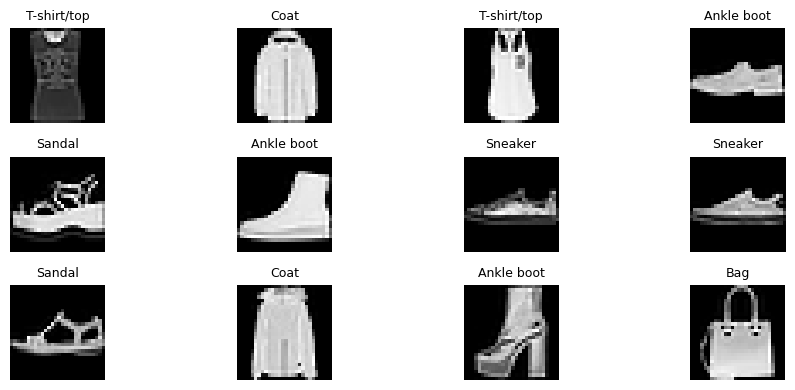

In [3]:
def show_examples(X, y, n=12):
    plt.figure(figsize=(10,4))
    idxs = np.random.choice(len(X), n, replace=False)
    for i, idx in enumerate(idxs, 1):
        plt.subplot(3, 4, i)
        plt.imshow(X[idx,:,:,0], cmap="gray")
        plt.title(class_names[int(y[idx])], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(X_train, y_train, n=12)


## 3) Definir un modelo CNN base

Arquitectura típica: Conv → ReLU → Pool → Conv → ReLU → Pool → Dense → Salida.


In [4]:
def build_cnn_base(dropout_rate=0.0):
    model = tf.keras.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(32, (3,3), padding="same", activation="relu", name="conv1"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), padding="same", activation="relu", name="conv2"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])
    return model

model = build_cnn_base(dropout_rate=0.0)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4) Entrenamiento (con validación)

Usamos `EarlyStopping` para parar si la validación no mejora.


Epoch 1/15


2026-03-09 17:34:46.588653: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.


422/422 ━━━━━━━━━━━━━━━━━━━━ 101s 232ms/step - accuracy: 0.8229 - loss: 0.4939 - val_accuracy: 0.8610 - val_loss: 0.3965
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 154s 260ms/step - accuracy: 0.8869 - loss: 0.3190 - val_accuracy: 0.8900 - val_loss: 0.3052
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 151s 283ms/step - accuracy: 0.9018 - loss: 0.2753 - val_accuracy: 0.9025 - val_loss: 0.2730
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 124s 242ms/step - accuracy: 0.9130 - loss: 0.2432 - val_accuracy: 0.9050 - val_loss: 0.2619
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 109s 259ms/step - accuracy: 0.9200 - loss: 0.2200 - val_accuracy: 0.9115 - val_loss: 0.2420
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 55s 131ms/step - accuracy: 0.9266 - loss: 0.1987 - val_accuracy: 0.9118 - val_loss: 0.2365
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 104s 247ms/step - accuracy: 0.9339 - loss: 0.1827 - val_accuracy: 0.9115 - val_loss: 0.2424
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 257ms/step - accuracy: 0.9386 - loss: 0.167

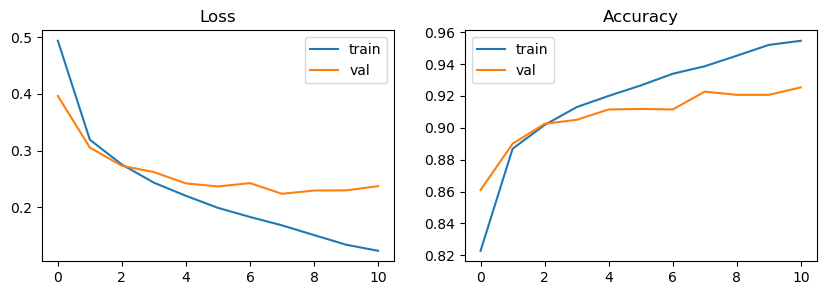

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.show()


## 5) Evaluación en test + Matriz de confusión


In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss={test_loss:.4f} | Test acc={test_acc:.4f}")

y_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))


2026-03-09 17:56:55.015453: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


Test loss=0.2374 | Test acc=0.9168


2026-03-09 17:57:00.310241: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


              precision    recall  f1-score   support

 T-shirt/top       0.82      0.90      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.88      0.87      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.87      0.87      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.81      0.71      0.76      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



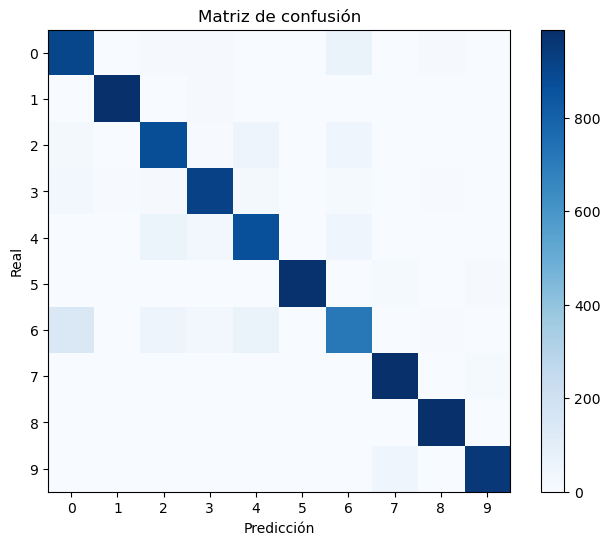

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))
plt.show()


## 6) Visualizar errores típicos

Mostramos ejemplos donde el modelo se equivoca.


Errores: 832


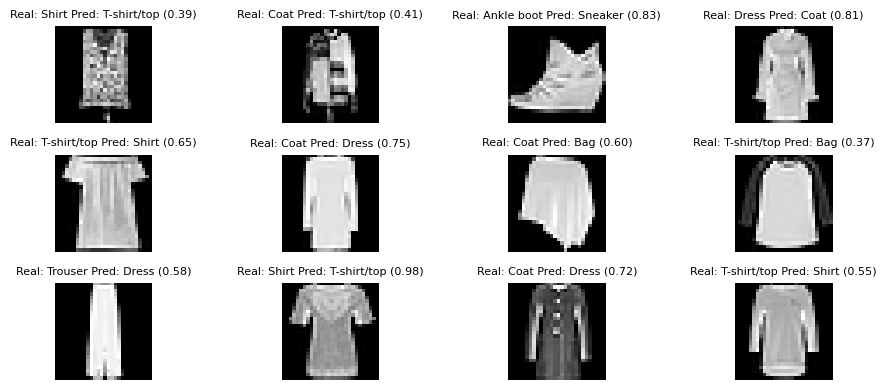

In [8]:
wrong = np.where(y_pred != y_test)[0]
print("Errores:", len(wrong))

def show_mistakes(X, y_true, y_pred, y_proba, n=12):
    if len(wrong) == 0:
        print("No hay errores.")
        return
    idxs = np.random.choice(wrong, min(n, len(wrong)), replace=False)
    plt.figure(figsize=(10,4))
    for i, idx in enumerate(idxs, 1):
        plt.subplot(3,4,i)
        plt.imshow(X[idx,:,:,0], cmap="gray")
        t = class_names[int(y_true[idx])]
        p = class_names[int(y_pred[idx])]
        conf = float(np.max(y_proba[idx]))
        plt.title(f"Real: {t} Pred: {p} ({conf:.2f})", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_mistakes(X_test, y_test, y_pred, y_proba, n=12)

## 7) Visualización: kernels aprendidos (conv1)


kernels: (3, 3, 1, 32)


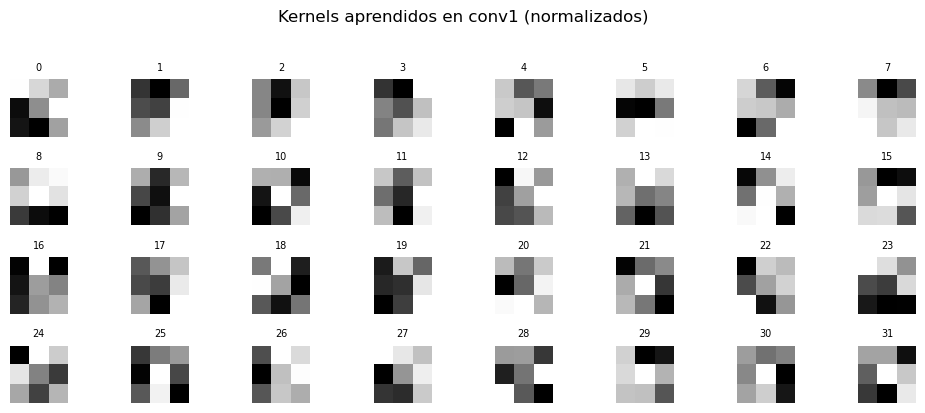

In [9]:
conv1 = model.get_layer("conv1")
kernels, biases = conv1.get_weights()  # (3,3,1,32)
print("kernels:", kernels.shape)

plt.figure(figsize=(10,4))
for i in range(kernels.shape[-1]):
    k = kernels[:,:,0,i]
    k_norm = (k - k.min()) / (k.max() - k.min() + 1e-9)
    plt.subplot(4,8,i+1)
    plt.imshow(k_norm, cmap="gray")
    plt.axis("off")
    plt.title(str(i), fontsize=7)
plt.suptitle("Kernels aprendidos en conv1 (normalizados)", y=1.02)
plt.tight_layout()
plt.show()


## 8) Visualización: feature maps (activaciones conv1)


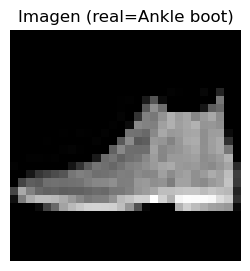

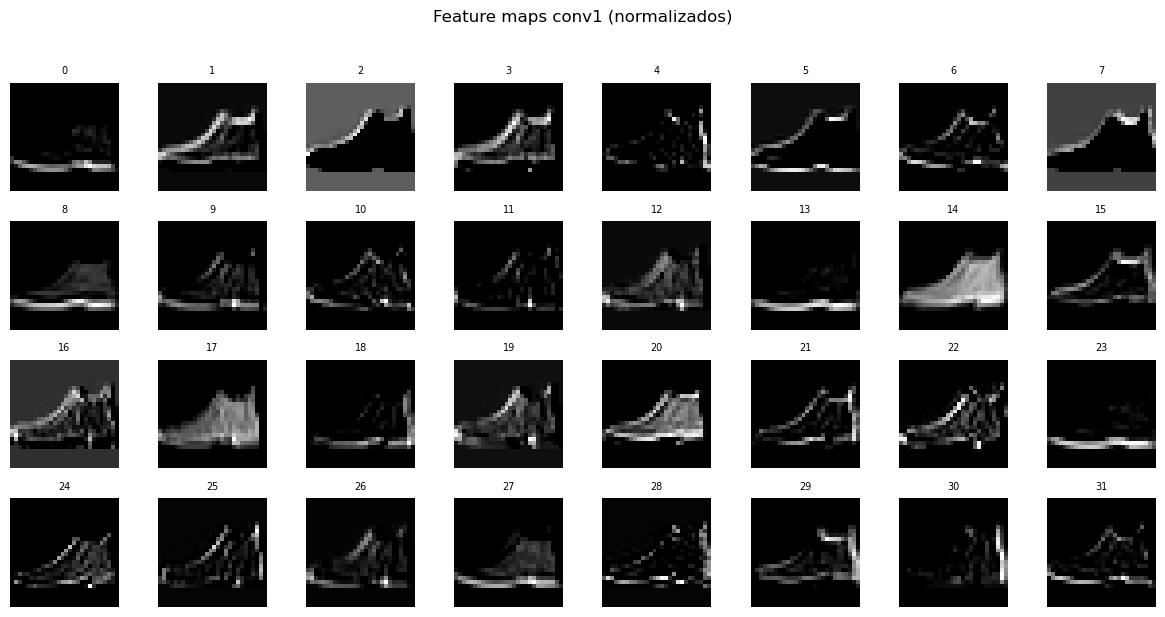

In [16]:
# Ensure the model is called with a dummy input to define its input shape
if not model.built:
    model.build(input_shape=(None, 28, 28, 1))  # Explicitly build the model

_ = model(tf.zeros((1, 28, 28, 1)))  # Dummy input to initialize the model

activation_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("conv1").output)

idx = 0
img = X_test[idx:idx+1]
acts = activation_model.predict(img, verbose=0)[0]  # (28,28,32)

plt.figure(figsize=(3,3))
plt.imshow(img[0,:,:,0], cmap="gray")
plt.title(f"Imagen (real={class_names[int(y_test[idx])]})")
plt.axis("off")
plt.show()

plt.figure(figsize=(12,6))
for i in range(32):
    a = acts[:,:,i]
    a_norm = (a - a.min()) / (a.max() - a.min() + 1e-9)
    plt.subplot(4,8,i+1)
    plt.imshow(a_norm, cmap="gray")
    plt.axis("off")
    plt.title(str(i), fontsize=7)
plt.suptitle("Feature maps conv1 (normalizados)", y=1.02)
plt.tight_layout()
plt.show()

## 9) Experimento 1 — Profundidad

Comparamos un modelo **pequeño** vs **más profundo**.


2026-03-09 18:12:46.813164: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.


CNN small: test_acc=0.8962


2026-03-09 18:16:37.560275: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.


CNN deeper: test_acc=0.9201


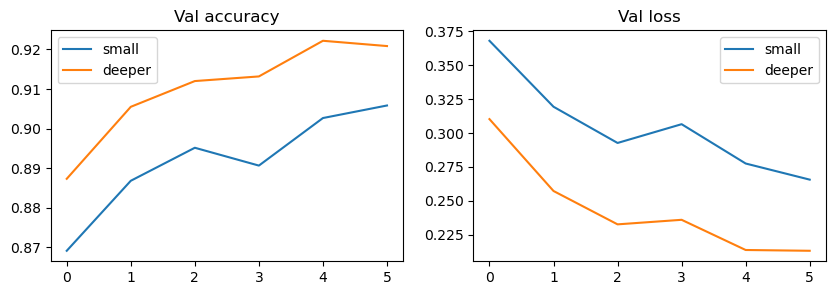

In [17]:
def build_cnn_small():
    m = tf.keras.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(16, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return m

def build_cnn_deeper(dropout_rate=0.0):
    m = tf.keras.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])
    return m

def train_quick(m, name, epochs=6):
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    h = m.fit(X_train, y_train, validation_split=0.1, epochs=epochs, batch_size=128, verbose=0)
    tl, ta = m.evaluate(X_test, y_test, verbose=0)
    print(f"{name}: test_acc={ta:.4f}")
    return h

small = build_cnn_small()
deep  = build_cnn_deeper(dropout_rate=0.0)

h_small = train_quick(small, "CNN small", epochs=6)
h_deep  = train_quick(deep,  "CNN deeper", epochs=6)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(h_small.history["val_accuracy"], label="small")
plt.plot(h_deep.history["val_accuracy"], label="deeper")
plt.title("Val accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(h_small.history["val_loss"], label="small")
plt.plot(h_deep.history["val_loss"], label="deeper")
plt.title("Val loss"); plt.legend()
plt.show()


## 10) Experimento 2 — Regularización con Dropout


Deeper no-dropout: test_acc=0.9246
Deeper dropout=0.3: test_acc=0.9228


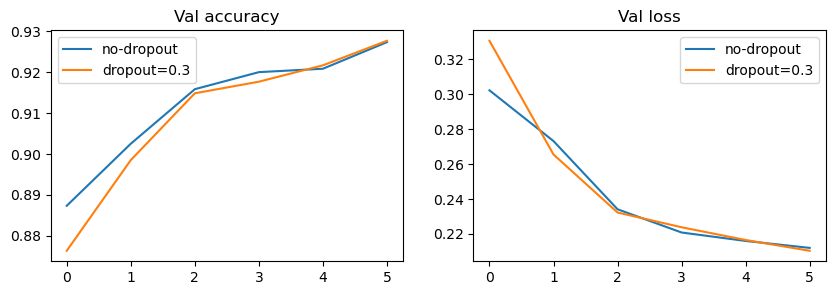

In [18]:
deep_no = build_cnn_deeper(dropout_rate=0.0)
deep_do = build_cnn_deeper(dropout_rate=0.3)

h_no = train_quick(deep_no, "Deeper no-dropout", epochs=6)
h_do = train_quick(deep_do, "Deeper dropout=0.3", epochs=6)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(h_no.history["val_accuracy"], label="no-dropout")
plt.plot(h_do.history["val_accuracy"], label="dropout=0.3")
plt.title("Val accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(h_no.history["val_loss"], label="no-dropout")
plt.plot(h_do.history["val_loss"], label="dropout=0.3")
plt.title("Val loss"); plt.legend()
plt.show()


## 11) Conclusiones guiadas

1. ¿Qué cambia al aumentar profundidad?
2. ¿Qué síntomas de sobreajuste aparecen en curvas?
3. ¿El dropout mejora validación? ¿En qué casos?
4. ¿Qué filtros de conv1 parecen “bordes” o “diagonales”?
5. ¿Qué clases se confunden más en la matriz de confusión?
